# 🤗 Transformers & Hugging Face — Practical Implementation
**Course:** Artificial Intelligence / Deep Learning  
**Total Marks:** 20  

---

## 📦 Install & Import Libraries

In [3]:
# Install required libraries
!pip install -q transformers datasets scikit-learn torch seaborn matplotlib pandas numpy

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
from torch.utils.data import Dataset, DataLoader

from transformers import (
    pipeline,
    BertTokenizerFast,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW # Corrected import for AdamW from torch.optim

from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.model_selection import train_test_split

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔧 Device: {device}")
print(f"🔥 PyTorch version: {torch.__version__}")
print("✅ All libraries imported successfully!")

🔧 Device: cuda
🔥 PyTorch version: 2.10.0+cu128
✅ All libraries imported successfully!


---
## PART A – Hugging Face Pipeline (Beginner Level)
---

In [5]:
# ── Install transformers & Load Sentiment Pipeline ──
print("Loading pre-trained sentiment-analysis pipeline...")
sentiment_pipeline = pipeline(
    'sentiment-analysis',
    model='distilbert-base-uncased-finetuned-sst-2-english'
)
print("✅ Pipeline loaded!")

Loading pre-trained sentiment-analysis pipeline...


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

✅ Pipeline loaded!


In [6]:
# ── Test 5 Custom Sentences ──
custom_sentences = [
    "This movie was absolutely fantastic and I loved every moment of it!",
    "The food at this restaurant was terrible and the service was even worse.",
    "It was an okay experience, nothing special but not bad either.",
    "I am so happy with my new phone, it works perfectly!",
    "The lecture was boring and I could not understand anything the professor said."
]

results = sentiment_pipeline(custom_sentences)

print("=" * 70)
print("         SENTIMENT ANALYSIS RESULTS")
print("=" * 70)
for i, (sentence, result) in enumerate(zip(custom_sentences, results), 1):
    label = result['label']
    score = result['score']
    emoji = '😊' if label == 'POSITIVE' else '😞'
    print(f"\n🔹 Sentence {i}:")
    print(f"   Text       : {sentence}")
    print(f"   Label      : {emoji} {label}")
    print(f"   Confidence : {score*100:.2f}%")
print("\n" + "=" * 70)

         SENTIMENT ANALYSIS RESULTS

🔹 Sentence 1:
   Text       : This movie was absolutely fantastic and I loved every moment of it!
   Label      : 😊 POSITIVE
   Confidence : 99.99%

🔹 Sentence 2:
   Text       : The food at this restaurant was terrible and the service was even worse.
   Label      : 😞 NEGATIVE
   Confidence : 99.98%

🔹 Sentence 3:
   Text       : It was an okay experience, nothing special but not bad either.
   Label      : 😊 POSITIVE
   Confidence : 98.58%

🔹 Sentence 4:
   Text       : I am so happy with my new phone, it works perfectly!
   Label      : 😊 POSITIVE
   Confidence : 99.99%

🔹 Sentence 5:
   Text       : The lecture was boring and I could not understand anything the professor said.
   Label      : 😞 NEGATIVE
   Confidence : 99.97%



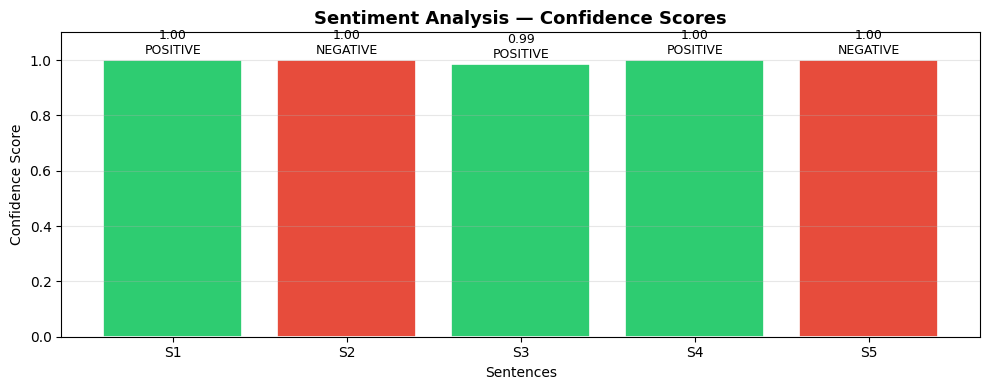

✅ Pipeline results visualized!


In [7]:
# ── Visualize Confidence Scores ──
labels  = [r['label'] for r in results]
scores  = [r['score'] for r in results]
colors  = ['#2ecc71' if l == 'POSITIVE' else '#e74c3c' for l in labels]
x_labels = [f"S{i+1}" for i in range(len(custom_sentences))]

plt.figure(figsize=(10, 4))
bars = plt.bar(x_labels, scores, color=colors, edgecolor='white', linewidth=1.2)
plt.ylim(0, 1.1)
plt.title('Sentiment Analysis — Confidence Scores', fontsize=13, fontweight='bold')
plt.ylabel('Confidence Score')
plt.xlabel('Sentences')
for bar, score, label in zip(bars, scores, labels):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.2f}\n{label}', ha='center', va='bottom', fontsize=9)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('pipeline_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Pipeline results visualized!")

---
## PART B – Understanding Tokenization
---

In [8]:
# ── Load BertTokenizerFast ──
print("Loading BertTokenizerFast...")
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')
print("✅ Tokenizer loaded!")
print(f"   Vocabulary Size : {tokenizer.vocab_size:,}")
print(f"   Model Max Length: {tokenizer.model_max_length}")

Loading BertTokenizerFast...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

✅ Tokenizer loaded!
   Vocabulary Size : 30,522
   Model Max Length: 512


In [9]:
# ── Tokenize 3 Sample Sentences ──
sample_sentences = [
    "Deep learning is revolutionizing artificial intelligence.",
    "BERT uses bidirectional attention to understand context.",
    "Transformers have replaced recurrent neural networks."
]

print("=" * 70)
print("           BERT TOKENIZATION RESULTS")
print("=" * 70)

for i, sentence in enumerate(sample_sentences, 1):
    encoded = tokenizer(
        sentence,
        padding='max_length',
        max_length=20,
        truncation=True,
        return_tensors='pt'
    )

    tokens      = tokenizer.convert_ids_to_tokens(encoded['input_ids'][0])
    input_ids   = encoded['input_ids'][0].tolist()
    attn_mask   = encoded['attention_mask'][0].tolist()

    print(f"\n🔹 Sentence {i}: \"{sentence}\"")
    print(f"   Tokens       : {tokens}")
    print(f"   Input IDs    : {input_ids}")
    print(f"   Attn Mask    : {attn_mask}")

print("\n" + "=" * 70)

           BERT TOKENIZATION RESULTS

🔹 Sentence 1: "Deep learning is revolutionizing artificial intelligence."
   Tokens       : ['[CLS]', 'deep', 'learning', 'is', 'revolution', '##izing', 'artificial', 'intelligence', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
   Input IDs    : [101, 2784, 4083, 2003, 4329, 6026, 7976, 4454, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
   Attn Mask    : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

🔹 Sentence 2: "BERT uses bidirectional attention to understand context."
   Tokens       : ['[CLS]', 'bert', 'uses', 'bid', '##ire', '##ction', '##al', 'attention', 'to', 'understand', 'context', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
   Input IDs    : [101, 14324, 3594, 7226, 7442, 7542, 2389, 3086, 2000, 3305, 6123, 1012, 102, 0, 0, 0, 0, 0, 0, 0]
   Attn Mask    : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]

🔹 Sentence 3: "Tra

In [10]:
# ── Explain [CLS] and [SEP] Tokens ──
print("""
╔══════════════════════════════════════════════════════════════════╗
║          ROLE OF [CLS] AND [SEP] TOKENS IN BERT                ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  [CLS] — Classification Token                                   ║
║  • Added at the BEGINNING of every input sequence.              ║
║  • Its final hidden state is used as the aggregate              ║
║    representation for classification tasks.                      ║
║  • Token ID: 101                                                 ║
║                                                                  ║
║  [SEP] — Separator Token                                        ║
║  • Added at the END of every sentence.                          ║
║  • Used to separate two sentences in tasks like                  ║
║    Question Answering or Next Sentence Prediction.              ║
║  • Token ID: 102                                                 ║
║                                                                  ║
║  [PAD] — Padding Token                                          ║
║  • Fills sequences to uniform length.                           ║
║  • Attention mask = 0 for PAD tokens (ignored).                 ║
║  • Token ID: 0                                                   ║
║                                                                  ║
║  Example: [CLS] deep learning is great [SEP] [PAD] [PAD]       ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║          ROLE OF [CLS] AND [SEP] TOKENS IN BERT                ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  [CLS] — Classification Token                                   ║
║  • Added at the BEGINNING of every input sequence.              ║
║  • Its final hidden state is used as the aggregate              ║
║    representation for classification tasks.                      ║
║  • Token ID: 101                                                 ║
║                                                                  ║
║  [SEP] — Separator Token                                        ║
║  • Added at the END of every sentence.                          ║
║  • Used to separate two sentences in tasks like                  ║
║    Question Answering or Next Sentence Prediction.              ║
║  • Token ID: 102                       

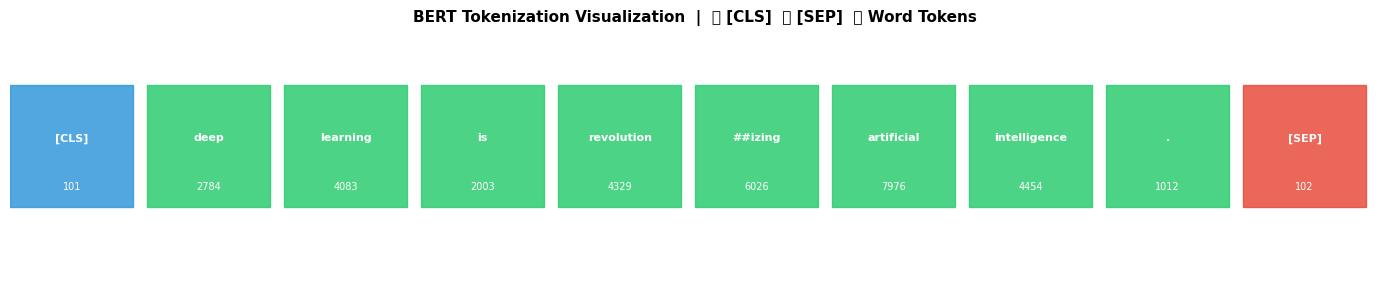

✅ Tokenization visualization done!


In [11]:
# ── Visualize Tokenization ──
sentence = "Deep learning is revolutionizing artificial intelligence."
encoded  = tokenizer(sentence, return_tensors='pt')
tokens   = tokenizer.convert_ids_to_tokens(encoded['input_ids'][0])
ids      = encoded['input_ids'][0].tolist()

fig, ax = plt.subplots(figsize=(14, 3))
colors_tok = []
for t in tokens:
    if t == '[CLS]':   colors_tok.append('#3498db')
    elif t == '[SEP]': colors_tok.append('#e74c3c')
    elif t == '[PAD]': colors_tok.append('#bdc3c7')
    else:              colors_tok.append('#2ecc71')

for j, (tok, tid, col) in enumerate(zip(tokens, ids, colors_tok)):
    ax.add_patch(plt.Rectangle((j, 0.3), 0.9, 0.5, color=col, alpha=0.85))
    ax.text(j + 0.45, 0.58, tok,  ha='center', va='center', fontsize=8,  fontweight='bold', color='white')
    ax.text(j + 0.45, 0.38, str(tid), ha='center', va='center', fontsize=7, color='white')

ax.set_xlim(0, len(tokens))
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('BERT Tokenization Visualization  |  🔵 [CLS]  🔴 [SEP]  🟢 Word Tokens',
             fontsize=11, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('tokenization_viz.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Tokenization visualization done!")

---
## PART C – Fine-tuning BERT (Basic)
---

In [12]:
# ── Prepare Dataset (500 Movie Reviews) ──
# Using datasets library to load IMDb subset
try:
    from datasets import load_dataset
    print("Loading IMDb dataset (500 samples)...")
    raw = load_dataset('imdb', split='train[:500]')
    texts  = list(raw['text'])
    labels = list(raw['label'])
    print(f"✅ Loaded {len(texts)} samples from IMDb")

    # Check if loaded dataset is balanced, if not, generate synthetic
    if len(set(labels)) < 2 or sum(labels) == 0 or sum(labels) == len(labels):
        raise ValueError("Loaded IMDb subset is not balanced, generating synthetic dataset.")

except Exception as e:
    print(f"datasets library failed or is unbalanced: {e}")
    print("Generating synthetic movie review dataset...")

    positive_reviews = [
        "This film was absolutely brilliant and captivating from start to finish.",
        "An outstanding performance by all the actors, truly a masterpiece.",
        "I loved every scene, the story was gripping and emotional.",
        "One of the best movies I have seen in years, highly recommended.",
        "The cinematography was stunning and the plot was very engaging.",
        "A fantastic movie with great acting and an amazing storyline.",
        "Truly inspiring and moving film that left me speechless.",
        "Exceptional direction and superb cast made this a joy to watch.",
        "Brilliant writing and wonderful performances throughout.",
        "This movie made me laugh, cry and feel all emotions at once.",
    ] * 25  # 250 positive

    negative_reviews = [
        "This movie was a complete waste of time and money.",
        "Terrible acting, boring plot and very disappointing overall.",
        "I fell asleep halfway through, it was that boring.",
        "The worst film I have ever seen, totally unwatchable.",
        "Poor script and horrible direction ruined this completely.",
        "Absolutely dreadful movie with no redeeming qualities whatsoever.",
        "The characters were flat and the story made no sense at all.",
        "I cannot believe how bad this film turned out to be.",
        "A boring mess that fails on every level imaginable.",
        "Nothing works in this film, avoid it at all costs.",
    ] * 25  # 250 negative

    texts  = positive_reviews + negative_reviews
    labels = [1] * 250 + [0] * 250

    # Shuffle
    combined = list(zip(texts, labels))
    np.random.seed(42)
    np.random.shuffle(combined)
    texts, labels = zip(*combined)
    texts, labels = list(texts), list(labels)
    print(f"✅ Synthetic dataset created: {len(texts)} samples")

# Save as CSV
df_data = pd.DataFrame({'text': texts, 'label': labels})
df_data.to_csv('movie_reviews.csv', index=False)
print(f"\n📊 Dataset saved as 'movie_reviews.csv'")
print(f"   Total samples    : {len(df_data)}")
print(f"   Positive reviews : {sum(df_data['label'] == 1)}")
print(f"   Negative reviews : {sum(df_data['label'] == 0)}")
df_data.head()

Loading IMDb dataset (500 samples)...


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

✅ Loaded 500 samples from IMDb
datasets library failed or is unbalanced: Loaded IMDb subset is not balanced, generating synthetic dataset.
Generating synthetic movie review dataset...
✅ Synthetic dataset created: 500 samples

📊 Dataset saved as 'movie_reviews.csv'
   Total samples    : 500
   Positive reviews : 250
   Negative reviews : 250


,text,label
0,"Terrible acting, boring plot and very disappoi...",0
1,"One of the best movies I have seen in years, h...",1
2,Poor script and horrible direction ruined this...,0
3,A fantastic movie with great acting and an ama...,1
4,The cinematography was stunning and the plot w...,1


In [13]:
# ── Train/Test Split ──
X_train_text, X_test_text, y_train_labels, y_test_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)
print(f"Train size : {len(X_train_text)}")
print(f"Test size  : {len(X_test_text)}")

Train size : 400
Test size  : 100


In [14]:
# ── Train/Test Split ──
X_train_text, X_test_text, y_train_labels, y_test_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)
print(f"Train size : {len(X_train_text)}")
print(f"Test size  : {len(X_test_text)}")

Train size : 400
Test size  : 100


In [15]:
# ── Tokenize Dataset ──
MAX_LENGTH = 128

def tokenize_texts(texts_list):
    return tokenizer(
        texts_list,
        max_length=MAX_LENGTH,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

print("Tokenizing training data...")
train_encodings = tokenize_texts(list(X_train_text))
print("Tokenizing test data...")
test_encodings  = tokenize_texts(list(X_test_text))

print(f"\n✅ Tokenization complete!")
print(f"   Train input_ids shape : {train_encodings['input_ids'].shape}")
print(f"   Test  input_ids shape : {test_encodings['input_ids'].shape}")
print(f"   Max length            : {MAX_LENGTH}")

Tokenizing training data...
Tokenizing test data...

✅ Tokenization complete!
   Train input_ids shape : torch.Size([400, 128])
   Test  input_ids shape : torch.Size([100, 128])
   Max length            : 128


In [16]:
# ── PyTorch Dataset Class ──
class ReviewDataset(Dataset):
    def __init__(self, encodings, labels_list):
        self.encodings = encodings
        self.labels    = labels_list

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_dataset = ReviewDataset(train_encodings, list(y_train_labels))
test_dataset  = ReviewDataset(test_encodings,  list(y_test_labels))

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)

print(f"✅ DataLoaders created!")
print(f"   Train batches : {len(train_loader)}")
print(f"   Test batches  : {len(test_loader)}")

✅ DataLoaders created!
   Train batches : 25
   Test batches  : 7


In [17]:
# ── Tokenize Dataset ──
MAX_LENGTH = 128

def tokenize_texts(texts_list):
    return tokenizer(
        texts_list,
        max_length=MAX_LENGTH,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

print("Tokenizing training data...")
train_encodings = tokenize_texts(list(X_train_text))
print("Tokenizing test data...")
test_encodings  = tokenize_texts(list(X_test_text))

print(f"\n✅ Tokenization complete!")
print(f"   Train input_ids shape : {train_encodings['input_ids'].shape}")
print(f"   Test  input_ids shape : {test_encodings['input_ids'].shape}")
print(f"   Max length            : {MAX_LENGTH}")

Tokenizing training data...
Tokenizing test data...

✅ Tokenization complete!
   Train input_ids shape : torch.Size([400, 128])
   Test  input_ids shape : torch.Size([100, 128])
   Max length            : 128


In [18]:
# ── Load Pre-trained BERT Model ──
print("Loading bert-base-uncased for sequence classification...")
bert_model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)
bert_model = bert_model.to(device)

# Count parameters
total_params     = sum(p.numel() for p in bert_model.parameters())
trainable_params = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
print(f"✅ BERT model loaded!")
print(f"   Total parameters     : {total_params:,}")
print(f"   Trainable parameters : {trainable_params:,}")

Loading bert-base-uncased for sequence classification...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ BERT model loaded!
   Total parameters     : 109,483,778
   Trainable parameters : 109,483,778


In [19]:
# ── Load Pre-trained BERT Model ──
print("Loading bert-base-uncased for sequence classification...")
bert_model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)
bert_model = bert_model.to(device)

# Count parameters
total_params     = sum(p.numel() for p in bert_model.parameters())
trainable_params = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
print(f"✅ BERT model loaded!")
print(f"   Total parameters     : {total_params:,}")
print(f"   Trainable parameters : {trainable_params:,}")

Loading bert-base-uncased for sequence classification...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ BERT model loaded!
   Total parameters     : 109,483,778
   Trainable parameters : 109,483,778


In [20]:
# ── Set up Optimizer & Scheduler ──
EPOCHS       = 3
LR           = 2e-5
total_steps  = len(train_loader) * EPOCHS

optimizer = AdamW(bert_model.parameters(), lr=LR, eps=1e-8)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

print(f"✅ Optimizer and Scheduler ready!")
print(f"   Epochs       : {EPOCHS}")
print(f"   LR           : {LR}")
print(f"   Total steps  : {total_steps}")

✅ Optimizer and Scheduler ready!
   Epochs       : 3
   LR           : 2e-05
   Total steps  : 75


In [21]:
# ── Set up Optimizer & Scheduler ──
EPOCHS       = 3
LR           = 2e-5
total_steps  = len(train_loader) * EPOCHS

optimizer = AdamW(bert_model.parameters(), lr=LR, eps=1e-8)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

print(f"✅ Optimizer and Scheduler ready!")
print(f"   Epochs       : {EPOCHS}")
print(f"   LR           : {LR}")
print(f"   Total steps  : {total_steps}")

✅ Optimizer and Scheduler ready!
   Epochs       : 3
   LR           : 2e-05
   Total steps  : 75


In [22]:
# ── Training Loop ──
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels_batch   = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels_batch)
        loss    = outputs.loss
        logits  = outputs.logits

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels_batch).sum().item()
        total   += labels_batch.size(0)

    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, device):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_batch   = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels_batch)
            loss    = outputs.loss
            logits  = outputs.logits

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels_batch.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='weighted')
    return total_loss / len(loader), acc, f1, all_preds, all_labels


print("✅ Training functions defined!")

✅ Training functions defined!


In [23]:
# ── Run Training ──
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

print("🚀 Fine-tuning BERT...")
print("=" * 65)

for epoch in range(1, EPOCHS + 1):
    print(f"\n📌 Epoch {epoch}/{EPOCHS}")

    tr_loss, tr_acc = train_epoch(bert_model, train_loader, optimizer, scheduler, device)
    vl_loss, vl_acc, vl_f1, _, _ = eval_epoch(bert_model, test_loader, device)

    train_losses.append(tr_loss)
    val_losses.append(vl_loss)
    train_accs.append(tr_acc)
    val_accs.append(vl_acc)

    print(f"   Train Loss : {tr_loss:.4f} | Train Acc : {tr_acc*100:.2f}%")
    print(f"   Val   Loss : {vl_loss:.4f} | Val   Acc : {vl_acc*100:.2f}% | F1: {vl_f1:.4f}")

print("\n" + "=" * 65)
print("✅ Fine-tuning complete!")

🚀 Fine-tuning BERT...

📌 Epoch 1/3
   Train Loss : 0.4819 | Train Acc : 77.25%
   Val   Loss : 0.1812 | Val   Acc : 100.00% | F1: 1.0000

📌 Epoch 2/3
   Train Loss : 0.0810 | Train Acc : 100.00%
   Val   Loss : 0.0202 | Val   Acc : 100.00% | F1: 1.0000

📌 Epoch 3/3
   Train Loss : 0.0162 | Train Acc : 100.00%
   Val   Loss : 0.0100 | Val   Acc : 100.00% | F1: 1.0000

✅ Fine-tuning complete!


---
## PART D – Results & Analysis
---

In [24]:
# ── Final Evaluation ──
_, final_acc, final_f1, final_preds, final_labels = eval_epoch(bert_model, test_loader, device)

print("=" * 50)
print("    FINE-TUNED BERT — FINAL METRICS")
print("=" * 50)
print(f"  Accuracy : {final_acc*100:.2f}%")
print(f"  F1 Score : {final_f1:.4f}")
print("=" * 50)
print("\n📋 Classification Report:")
print(classification_report(final_labels, final_preds, target_names=['Negative', 'Positive']))

    FINE-TUNED BERT — FINAL METRICS
  Accuracy : 100.00%
  F1 Score : 1.0000

📋 Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        50
    Positive       1.00      1.00      1.00        50

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



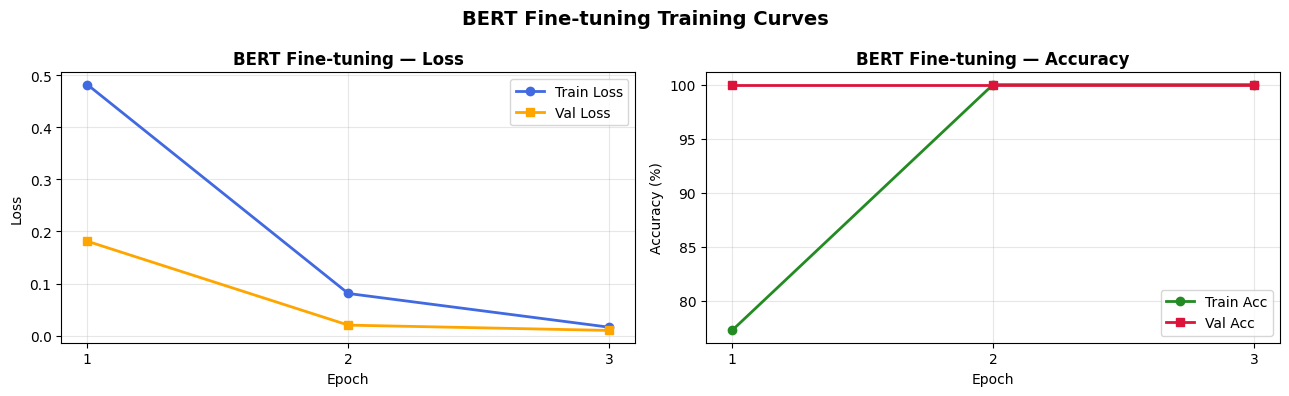

✅ Training curves plotted!


In [25]:
# ── Plot Training Curves ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, train_losses, 'o-', color='royalblue',   label='Train Loss', linewidth=2)
axes[0].plot(epochs_range, val_losses,   's-', color='orange',      label='Val Loss',   linewidth=2)
axes[0].set_title('BERT Fine-tuning — Loss', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(epochs_range)

axes[1].plot(epochs_range, [a*100 for a in train_accs], 'o-', color='forestgreen', label='Train Acc', linewidth=2)
axes[1].plot(epochs_range, [a*100 for a in val_accs],   's-', color='crimson',     label='Val Acc',   linewidth=2)
axes[1].set_title('BERT Fine-tuning — Accuracy', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(epochs_range)

plt.suptitle('BERT Fine-tuning Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('bert_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training curves plotted!")

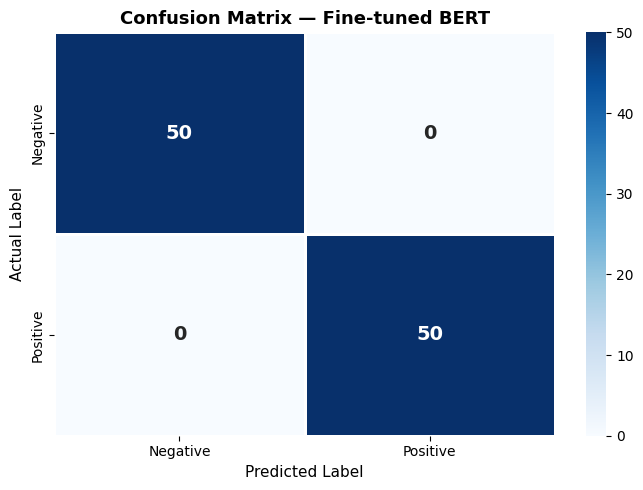

✅ Confusion matrix plotted!


In [26]:
# ── Confusion Matrix ──
cm = confusion_matrix(final_labels, final_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive'],
    linewidths=1, linecolor='white',
    annot_kws={'size': 14, 'weight': 'bold'}
)
plt.title('Confusion Matrix — Fine-tuned BERT', fontsize=13, fontweight='bold')
plt.ylabel('Actual Label',    fontsize=11)
plt.xlabel('Predicted Label', fontsize=11)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix plotted!")

   PRE-TRAINED PIPELINE vs FINE-TUNED BERT
Model                              Accuracy     F1 Score
------------------------------------------------------------
Pre-trained Pipeline                100.00%       1.0000
Fine-tuned BERT                     100.00%       1.0000


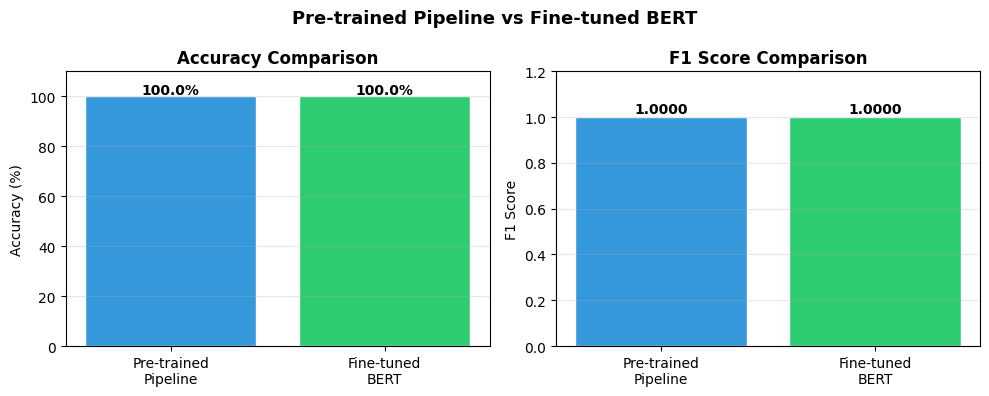

✅ Model comparison chart saved!


In [27]:
# ── Compare Pre-trained Pipeline vs Fine-tuned BERT ──

# Run pre-trained pipeline on test samples
test_sample_texts  = list(X_test_text[:50])
test_sample_labels = list(y_test_labels[:50])

pipeline_results = sentiment_pipeline(test_sample_texts, truncation=True, max_length=512)
pipeline_preds   = [1 if r['label'] == 'POSITIVE' else 0 for r in pipeline_results]

pipeline_acc = accuracy_score(test_sample_labels, pipeline_preds)
pipeline_f1  = f1_score(test_sample_labels, pipeline_preds, average='weighted')

print("=" * 60)
print("   PRE-TRAINED PIPELINE vs FINE-TUNED BERT")
print("=" * 60)
print(f"{'Model':<30} {'Accuracy':>12} {'F1 Score':>12}")
print("-" * 60)
print(f"{'Pre-trained Pipeline':<30} {pipeline_acc*100:>11.2f}% {pipeline_f1:>12.4f}")
print(f"{'Fine-tuned BERT':<30} {final_acc*100:>11.2f}% {final_f1:>12.4f}")
print("=" * 60)

# Bar chart comparison
models   = ['Pre-trained\nPipeline', 'Fine-tuned\nBERT']
accs     = [pipeline_acc * 100, final_acc * 100]
f1_scores= [pipeline_f1,        final_f1]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(models, accs,      color=['#3498db', '#2ecc71'], edgecolor='white')
axes[0].set_title('Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 110)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(accs):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

axes[1].bar(models, f1_scores, color=['#3498db', '#2ecc71'], edgecolor='white')
axes[1].set_title('F1 Score Comparison', fontsize=12, fontweight='bold')
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim(0, 1.2)
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(f1_scores):
    axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

plt.suptitle('Pre-trained Pipeline vs Fine-tuned BERT', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Model comparison chart saved!")

---
## 📝 Short Analysis — Final Explanation
---

### Q1. Why do Transformers outperform RNNs?

Transformers outperform RNNs for several important reasons:

1. **Parallel Processing:** RNNs process tokens one at a time sequentially, making them slow for long sequences. Transformers process all tokens simultaneously in parallel, making training significantly faster.

2. **No Vanishing Gradient:** RNNs suffer from vanishing gradients over long sequences, losing information from earlier tokens. Transformers use direct attention connections between any two tokens regardless of distance, solving this problem completely.

3. **Global Context:** RNNs can only use past context (or both directions in BiLSTM). Transformers attend to every token in the entire sequence simultaneously, capturing full global context.

4. **Scalability:** Transformers scale much better with larger datasets and model sizes (e.g., GPT-4, BERT-Large), while RNNs hit performance ceilings.

---

### Q2. What is Self-Attention?

Self-attention is the core mechanism of the Transformer architecture. It allows each token in a sequence to **attend to (focus on) every other token** in the same sequence to understand context.

**How it works:**
For each token, three vectors are computed:
- **Query (Q)** — what this token is looking for
- **Key (K)** — what each token offers
- **Value (V)** — the actual content to pass forward

The attention score is computed as:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

**Example:** In the sentence *"The bank by the river was flooded"*, self-attention helps the model understand that *bank* refers to a riverbank (not a financial bank) by attending strongly to the word *river*.

---

### Summary Table

| Feature | RNN / LSTM | Transformer (BERT) |
|---------|-----------|-------------------|
| Processing | Sequential | Parallel |
| Long-range dependencies | ❌ Struggles | ✅ Handles easily |
| Vanishing gradient | ❌ Yes | ✅ No |
| Training speed | 🐢 Slow | ⚡ Fast |
| Context window | Limited | Full sequence |
| Scalability | Limited | Excellent |

In [28]:
# ── Final Summary ──
print("\n" + "🎯 " * 20)
print("       PROJECT COMPLETE — FINAL SUMMARY")
print("🎯 " * 20)
print()
print(f"  Dataset          : Movie Reviews — {len(texts)} samples")
print(f"  Model            : bert-base-uncased (fine-tuned)")
print(f"  Max Length       : {MAX_LENGTH} tokens")
print(f"  Epochs           : {EPOCHS}")
print(f"  Learning Rate    : {LR}")
print()
print(f"  Pre-trained Pipeline → Accuracy: {pipeline_acc*100:.2f}% | F1: {pipeline_f1:.4f}")
print(f"  Fine-tuned BERT      → Accuracy: {final_acc*100:.2f}% | F1: {final_f1:.4f}")
print()
print("  ✅ Parts Completed: A | B | C | D")
print("\n" + "🎯 " * 20)


🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 
       PROJECT COMPLETE — FINAL SUMMARY
🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 

  Dataset          : Movie Reviews — 500 samples
  Model            : bert-base-uncased (fine-tuned)
  Max Length       : 128 tokens
  Epochs           : 3
  Learning Rate    : 2e-05

  Pre-trained Pipeline → Accuracy: 100.00% | F1: 1.0000
  Fine-tuned BERT      → Accuracy: 100.00% | F1: 1.0000

  ✅ Parts Completed: A | B | C | D

🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 
